In [3]:
import torch
torch.__version__

'2.1.2+cpu'

In [6]:
import torchaudio
import torchvision
torchaudio.__version__
torchvision.__version__

'0.16.2+cpu'

In [7]:
# Import aller Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from PIL import Image
import io
import os
import glob
import base64
import cv2

In [8]:
# Trainings- und Validierungsdatensatz laden
m14x14 = pd.read_csv('class_128_14x14.csv')
m14x14.head(6)

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p186,p187,p188,p189,p190,p191,p192,p193,p194,p195
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Datensatz aufbereiten: Skalieren auf Wertebereich zwischen 0 und 1 UND Splitten in Train und Test.
feature_spalten = []
for i in range(0, 196):
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = m14x14['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test

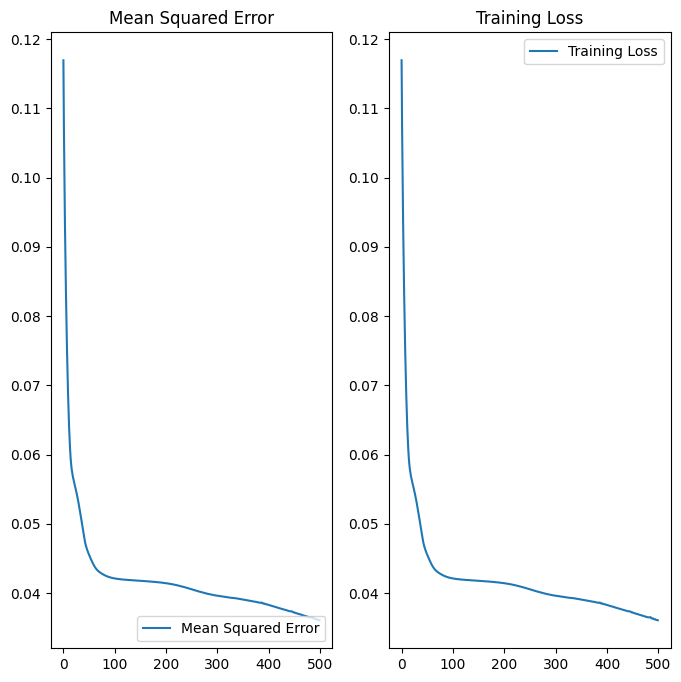

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Definiere das Modell
class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.layer1 = nn.Linear(196, 100)
        self.layer2 = nn.Linear(100, 50)
        self.layer3 = nn.Linear(50, 2)
        self.layer4 = nn.Linear(2, 50)
        self.layer5 = nn.Linear(50, 100)
        self.layer6 = nn.Linear(100, 196)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.activation(self.layer3(x))
        x = self.activation(self.layer4(x))
        x = self.activation(self.layer5(x))
        x = self.activation(self.layer6(x))
        return x

model = CustomModel()

# Definiere die Verlustfunktion und den Optimierer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Anzahl der Epochen
numepochs = 500

# Konvertiere die Daten nach PyTorch-Tensoren
X_train_torch = torch.Tensor(X_train)

# Trainingsschleife
loss_history = []

for epoch in range(numepochs):
    # Vorwärtsdurchlauf
    outputs = model(X_train_torch)
    loss = criterion(outputs, X_train_torch)
    
    # Rückwärtsdurchlauf und Optimierung
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# Plot der Ergebnisse
epochs_range = range(numepochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_history, label='Mean Squared Error')
plt.legend(loc='lower right')
plt.title('Mean Squared Error')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_history, label='Training Loss')
plt.legend(loc='upper right')
plt.title('Training Loss')

plt.show()

Aufloesung in DPI: 100.0


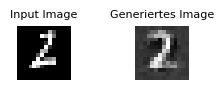

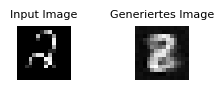

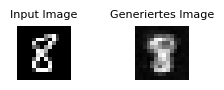

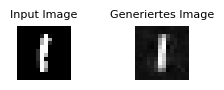

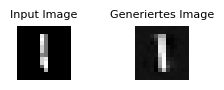

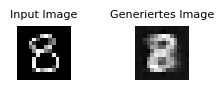

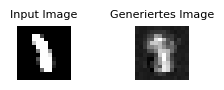

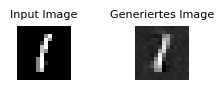

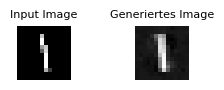

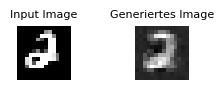

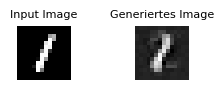

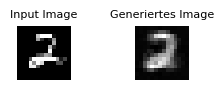

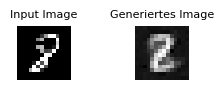

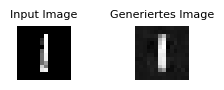

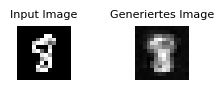

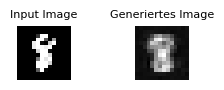

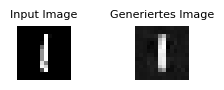

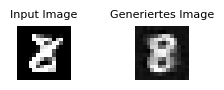

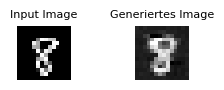

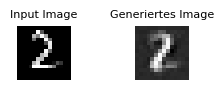

In [20]:
dpi = mpl.rcParams['figure.dpi']  #Kommentar: aktuelle DPI-Auflösung auslesen
print("Aufloesung in DPI:", dpi)

bilderzahl = 20
model.eval()

for i in range(0,bilderzahl):
    #x_reconst = model.predict(X_test[i].reshape(-1,196))
    new_data_torch = torch.Tensor(X_test[i])
    with torch.no_grad():
        x_reconst = model(new_data_torch)
    plt.figure(figsize=(280 / float(dpi), 70 / float(dpi)))
    plt.subplot(1,2,1)
    plt.axis('off')
    plt.imshow(X_test[i].reshape(14,14), 'gray')
    plt.title('Input Image', fontsize = 8)
    plt.subplot(1,2,2)
    plt.axis('off')
    plt.imshow(x_reconst.reshape(14,14), 'gray')
    plt.title('Generiertes Image', fontsize = 8)
    plt.show()